# White-POC Lambda-To-Within Bridge

This notebook connects two observations using the White-POC outputs only:

1. As `lambda` increases, Half Edge becomes more correlated with dissimilarity and less correlated with Moran.
2. Increasing `lambda` gives more weight to same-tract products, so the next question is whether those within terms are mechanically inflated by tract-level count variance.

The Half Edge values come directly from the White-POC CSV. The graph JSONs are loaded only to compute `within_xx`, `within_xy`, `within_yy`, `between_xx`, `between_xy`, and `between_yy`.

In [1]:
from pathlib import Path

from IPython.display import display
import gerrychain
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

relative_csv = Path(
    "outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_poc.csv"
)

for candidate_root in [Path.cwd(), *Path.cwd().parents]:
    if (candidate_root / relative_csv).exists() and (
        candidate_root / "pipeline" / "calculate_metrics.py"
    ).exists():
        project_root = candidate_root
        break
else:
    raise FileNotFoundError(f"Could not find {relative_csv} from {Path.cwd()}")

csv_path = project_root / relative_csv

X_COL = "POC"
Y_COL = "WHITE"
TOT_COL = "TOTPOP"

lambda_columns = {
    "0": "half_edge_lam_0_angle_1",
    "1": "half_edge_lam_1_angle_1",
    "10": "half_edge_lam_10_angle_1",
    "infinity": "half_edge_lam_lim_angle_1",
}
comparison_columns = ["dissimilarity", "moran"]

csv_path

PosixPath('/Users/maria/Documents/capy-bara/outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage/white_poc.csv')

## Load White-POC Metrics

The CSV is the source of truth for the Half Edge, dissimilarity, and Moran values. The checks below make the notebook fail early if it is accidentally pointed at another population pairing or if one of the expected lambda columns is missing.

In [2]:
df = pd.read_csv(csv_path)

required_columns = [
    "filename",
    "x_col",
    "y_col",
    "tot_col",
    "total_nodes",
    "total_edges",
    "total_poc",
    "total_white",
    "total_x",
    *lambda_columns.values(),
    *comparison_columns,
]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}")

unexpected_x_cols = sorted(df.loc[df["x_col"].notna() & (df["x_col"] != X_COL), "x_col"].unique())
unexpected_y_cols = sorted(df.loc[df["y_col"].notna() & (df["y_col"] != Y_COL), "y_col"].unique())
unexpected_tot_cols = sorted(
    df.loc[df["tot_col"].notna() & (df["tot_col"] != TOT_COL), "tot_col"].unique()
)
if unexpected_x_cols or unexpected_y_cols or unexpected_tot_cols:
    raise ValueError(
        "Expected White-POC rows only, but found "
        f"x_col={unexpected_x_cols}, y_col={unexpected_y_cols}, tot_col={unexpected_tot_cols}"
    )

df["year"] = df["filename"].str.extract(r"study_areas/(\d{4})/").astype(int)
df["cbsa"] = df["filename"].str.extract(r"tracts_in_cbsa_(\d+)_")
df["area_key"] = df["year"].astype(str) + " CBSA " + df["cbsa"]

metric_rows = df.dropna(subset=[*lambda_columns.values(), *comparison_columns]).copy()
print(f"Loaded {len(df):,} rows from {csv_path.name}; {len(metric_rows):,} have complete metric columns.")

metric_rows[
    [
        "area_key",
        "total_nodes",
        "total_edges",
        "total_poc",
        "total_white",
        "dissimilarity",
        "moran",
        *lambda_columns.values(),
    ]
].head()

Loaded 1,939 rows from white_poc.csv; 1,939 have complete metric columns.


,area_key,total_nodes,total_edges,total_poc,total_white,dissimilarity,moran,half_edge_lam_0_angle_1,half_edge_lam_1_angle_1,half_edge_lam_10_angle_1,half_edge_lam_lim_angle_1
0,2020 CBSA 22520,41,101,31059,119732,0.326354,0.280096,0.519890,0.524267,0.536908,0.544950
1,2020 CBSA 42700,33,78,35724,65511,0.286102,0.098390,0.508373,0.515872,0.535984,0.547705
2,2020 CBSA 27780,42,100,14092,119380,0.381676,0.545987,0.518816,0.523305,0.536110,0.544150
3,2020 CBSA 23900,27,58,13907,89945,0.189141,0.310168,0.503942,0.505644,0.510277,0.513024
4,2020 CBSA 37860,114,311,161425,348480,0.290752,0.648196,0.530204,0.533356,0.542537,0.548440


## Lambda Sweep

This reproduces the compact White-POC pattern from the earlier lambda notebook, focusing only on `angle_1`: as `lambda` rises, Half Edge moves toward dissimilarity and away from Moran.

,lambda,half_edge_column,n,corr_with_moran,corr_with_dissimilarity
0,0,half_edge_lam_0_angle_1,1939,0.721524,0.764274
1,1,half_edge_lam_1_angle_1,1939,0.681434,0.813164
2,10,half_edge_lam_10_angle_1,1939,0.575613,0.878024
3,infinity,half_edge_lam_lim_angle_1,1939,0.521857,0.890076


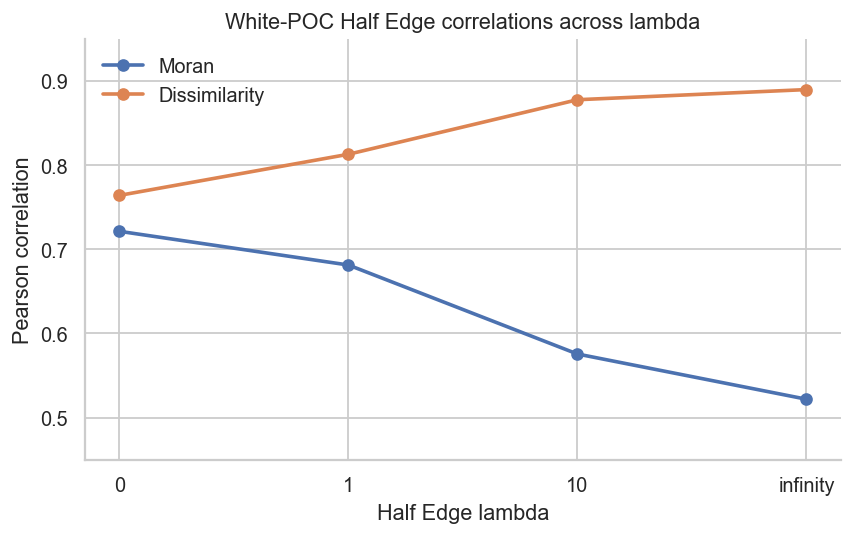

In [3]:
correlation_records = []

for lambda_label, half_edge_column in lambda_columns.items():
    complete = metric_rows[[half_edge_column, *comparison_columns]].dropna()
    correlation_records.append(
        {
            "lambda": lambda_label,
            "half_edge_column": half_edge_column,
            "n": len(complete),
            "corr_with_moran": complete[half_edge_column].corr(complete["moran"]),
            "corr_with_dissimilarity": complete[half_edge_column].corr(
                complete["dissimilarity"]
            ),
        }
    )

lambda_correlation_summary = pd.DataFrame(correlation_records)
display(lambda_correlation_summary)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
x_positions = np.arange(len(lambda_correlation_summary))

ax.plot(
    x_positions,
    lambda_correlation_summary["corr_with_moran"],
    marker="o",
    linewidth=2,
    label="Moran",
)
ax.plot(
    x_positions,
    lambda_correlation_summary["corr_with_dissimilarity"],
    marker="o",
    linewidth=2,
    label="Dissimilarity",
)

ax.set_xticks(x_positions, lambda_correlation_summary["lambda"])
ax.set_xlabel("Half Edge lambda")
ax.set_ylabel("Pearson correlation")
ax.set_ylim(0.45, 0.95)
ax.set_title("White-POC Half Edge correlations across lambda")
ax.legend(frameon=False)
plt.show()

## Why Lambda Points To The Within Terms

For `angle_1`, Half Edge is built from three product totals:

`xx(lambda) = lambda * within_xx + between_xx`

`xy(lambda) = lambda * within_xy + between_xy`

`yy(lambda) = lambda * within_yy + between_yy`

and then combines them as:

`0.5 * (xx / (xx + xy) + yy / (yy + xy))`

So `lambda=0` removes same-tract products and leaves only edge-neighbour products. Larger `lambda` gives more weight to `within_xx`, `within_xy`, and `within_yy`. The correlation sweep therefore suggests a narrower question: are the within terms large enough to pull Half Edge toward the within-only end of the metric?

## Compute Within And Between Product Terms

The graph JSONs are used only for decomposition. This cell does not rebuild the Half Edge values; it keeps the metric columns from the CSV as the source of truth.

In [5]:
decomposition_records = []
missing_graph_paths = []

for row_number, area in enumerate(metric_rows.itertuples(index=False), start=1):
    graph_path = project_root / area.filename
    if not graph_path.exists():
        missing_graph_paths.append(graph_path)
        continue

    graph = gerrychain.Graph.from_json(graph_path)
    node_order = list(graph.nodes())

    poc_counts = np.array([float(graph.nodes[node][X_COL]) for node in node_order], dtype=float)
    white_counts = np.array([float(graph.nodes[node][Y_COL]) for node in node_order], dtype=float)
    total_counts = np.array([float(graph.nodes[node][TOT_COL]) for node in node_order], dtype=float)

    poc_count_mean = poc_counts.mean()
    poc_count_var = poc_counts.var(ddof=0)
    poc_count_cv = poc_counts.std(ddof=0) / poc_count_mean if poc_count_mean > 0 else np.nan

    white_count_mean = white_counts.mean()
    white_count_cv = (
        white_counts.std(ddof=0) / white_count_mean if white_count_mean > 0 else np.nan
    )

    totpop_mean = total_counts.mean()
    totpop_cv = total_counts.std(ddof=0) / totpop_mean if totpop_mean > 0 else np.nan

    within_xx = float(np.sum(poc_counts * poc_counts))
    within_xy = float(np.sum(poc_counts * white_counts))
    within_yy = float(np.sum(white_counts * white_counts))

    between_xx = 0.0
    between_xy = 0.0
    between_yy = 0.0
    for node, neighbor in graph.edges():
        x_node = float(graph.nodes[node][X_COL])
        y_node = float(graph.nodes[node][Y_COL])
        x_neighbor = float(graph.nodes[neighbor][X_COL])
        y_neighbor = float(graph.nodes[neighbor][Y_COL])

        between_xx += x_node * x_neighbor + x_neighbor * x_node
        between_xy += x_node * y_neighbor + x_neighbor * y_node
        between_yy += y_node * y_neighbor + y_neighbor * y_node

    n_nodes = len(node_order)
    within_xx_per_node = within_xx / n_nodes if n_nodes else np.nan
    within_xx_inflation = (
        within_xx_per_node / (poc_count_mean**2) if poc_count_mean > 0 else np.nan
    )
    theoretical_inflation = 1 + poc_count_cv**2 if np.isfinite(poc_count_cv) else np.nan

    decomposition_records.append(
        {
            "filename": area.filename,
            "area_key": area.area_key,
            "within_xx": within_xx,
            "within_xy": within_xy,
            "within_yy": within_yy,
            "between_xx": between_xx,
            "between_xy": between_xy,
            "between_yy": between_yy,
            "poc_count_mean": poc_count_mean,
            "poc_count_var": poc_count_var,
            "poc_count_cv": poc_count_cv,
            "white_count_cv": white_count_cv,
            "totpop_cv": totpop_cv,
            "within_xx_per_node": within_xx_per_node,
            "within_xx_inflation": within_xx_inflation,
            "theoretical_inflation": theoretical_inflation,
        }
    )

    if row_number % 250 == 0:
        print(f"Loaded {row_number:,} graph JSONs...")

if missing_graph_paths:
    raise FileNotFoundError(f"Missing graph JSONs: {missing_graph_paths[:5]}")

decomposition = pd.DataFrame(decomposition_records)
within_diagnostics = metric_rows.merge(
    decomposition,
    on=["filename", "area_key"],
    how="inner",
    validate="one_to_one",
)

within_diagnostics["lambda_1_minus_0"] = (
    within_diagnostics["half_edge_lam_1_angle_1"]
    - within_diagnostics["half_edge_lam_0_angle_1"]
)
within_diagnostics["lambda_10_minus_0"] = (
    within_diagnostics["half_edge_lam_10_angle_1"]
    - within_diagnostics["half_edge_lam_0_angle_1"]
)
within_diagnostics["lambda_lim_minus_0"] = (
    within_diagnostics["half_edge_lam_lim_angle_1"]
    - within_diagnostics["half_edge_lam_0_angle_1"]
)

print(f"Loaded decomposition terms for {len(within_diagnostics):,} graph JSONs.")
within_diagnostics[
    [
        "area_key",
        "within_xx",
        "within_xy",
        "within_yy",
        "between_xx",
        "between_xy",
        "between_yy",
        "poc_count_cv",
        "within_xx_inflation",
        "lambda_lim_minus_0",
    ]
].head()

Loaded 250 graph JSONs...
Loaded 500 graph JSONs...
Loaded 750 graph JSONs...
Loaded 1,000 graph JSONs...
Loaded 1,250 graph JSONs...
Loaded 1,500 graph JSONs...
Loaded 1,750 graph JSONs...
Loaded decomposition terms for 1,939 graph JSONs.


,area_key,within_xx,within_xy,within_yy,between_xx,between_xy,between_yy,poc_count_cv,within_xx_inflation,lambda_lim_minus_0
0,2020 CBSA 22520,32826221.0,89477969.0,4.118065e+08,1.380726e+08,4.489902e+08,1.848668e+09,0.628632,1.395179,0.025060
1,2020 CBSA 42700,52878314.0,77331817.0,1.715726e+08,1.950466e+08,3.568525e+08,7.031129e+08,0.606072,1.367324,0.039333
2,2020 CBSA 27780,7633362.0,37244256.0,4.181092e+08,2.845715e+07,1.859862e+08,1.770300e+09,0.783857,1.614432,0.025335
3,2020 CBSA 23900,9565257.0,50909370.0,3.344126e+08,3.784340e+07,2.250359e+08,1.428739e+09,0.579090,1.335345,0.009082
4,2020 CBSA 37860,298538067.0,503094899.0,1.322805e+09,1.317231e+09,2.508061e+09,6.325031e+09,0.553226,1.306060,0.018236


## POC Count Variance And `within_xx`

The POC diagonal term is:

`within_xx / n = mean(POC_i^2)`

and the second moment identity gives:

`mean(POC_i^2) = mean(POC_i)^2 + var(POC_i)`

Dividing by `mean(POC_i)^2` makes this a unitless inflation factor:

`within_xx_inflation = 1 + poc_count_cv^2`

This is the simple bridge from tract-level count variance to an oversized same-tract `POC x POC` term.

In [6]:
within_diagnostics["within_xx_identity_error"] = (
    within_diagnostics["within_xx_inflation"]
    - within_diagnostics["theoretical_inflation"]
).abs()
max_identity_error = within_diagnostics["within_xx_identity_error"].max()

if max_identity_error > 1e-10:
    raise AssertionError(
        "within_xx_inflation should equal 1 + poc_count_cv^2; "
        f"max error was {max_identity_error}"
    )

print(f"Max identity error: {max_identity_error:.3e}")
within_diagnostics[
    [
        "area_key",
        "poc_count_mean",
        "poc_count_var",
        "poc_count_cv",
        "within_xx_per_node",
        "within_xx_inflation",
        "theoretical_inflation",
        "within_xx_identity_error",
    ]
].sort_values("within_xx_inflation", ascending=False).head(10)

Max identity error: 1.776e-15


,area_key,poc_count_mean,poc_count_var,poc_count_cv,within_xx_per_node,within_xx_inflation,theoretical_inflation,within_xx_identity_error
1868,1980 CBSA 15980,413.745455,1.979907e+06,3.400863,2.151092e+06,12.565869,12.565869,1.776357e-15
1185,1990 CBSA 24020,125.228571,1.736886e+05,3.327992,1.893708e+05,12.075531,12.075531,1.776357e-15
1654,1980 CBSA 24020,69.416667,3.898297e+04,2.844289,4.380164e+04,9.089978,9.089978,0.000000e+00
1743,1980 CBSA 29020,274.952381,4.724446e+05,2.499873,5.480434e+05,7.249366,7.249366,1.776357e-15
802,2000 CBSA 24020,172.454545,1.519990e+05,2.260714,1.817395e+05,6.110829,6.110829,0.000000e+00
1585,1980 CBSA 38940,705.675000,2.531687e+06,2.254760,3.029665e+06,6.083942,6.083942,8.881784e-16
1260,1990 CBSA 42540,70.028736,2.396271e+04,2.210506,2.886673e+04,5.886336,5.886336,8.881784e-16
1705,1980 CBSA 35840,494.906250,1.184634e+06,2.199222,1.429566e+06,5.836578,5.836578,8.881784e-16
1497,1990 CBSA 25180,277.977273,3.631689e+05,2.167929,4.404402e+05,5.699916,5.699916,8.881784e-16
1602,1980 CBSA 26580,121.619048,6.809628e+04,2.145656,8.288748e+04,5.603840,5.603840,1.776357e-15


## Does Within Inflation Track Lambda Movement?

These correlations are not a causal proof. They are a quick bridge check: if the lambda sweep is about the metric moving toward same-tract products, then areas with more inflated `within_xx` should tend to show larger differences between the edge-only and within-heavy Half Edge values.

In [7]:
predictor_columns = [
    "poc_count_cv",
    "within_xx_inflation",
    "white_count_cv",
    "totpop_cv",
]
movement_columns = ["lambda_1_minus_0", "lambda_10_minus_0", "lambda_lim_minus_0"]

movement_correlation_records = []
for predictor_column in predictor_columns:
    for movement_column in movement_columns:
        complete = within_diagnostics[[predictor_column, movement_column]].dropna()
        movement_correlation_records.append(
            {
                "predictor": predictor_column,
                "movement": movement_column,
                "n": len(complete),
                "pearson_corr": complete[predictor_column].corr(complete[movement_column]),
                "spearman_corr": complete[predictor_column].corr(
                    complete[movement_column], method="spearman"
                ),
            }
        )

movement_correlation_table = pd.DataFrame(movement_correlation_records)
movement_correlation_table

,predictor,movement,n,pearson_corr,spearman_corr
0,poc_count_cv,lambda_1_minus_0,1939,0.428787,0.456784
1,poc_count_cv,lambda_10_minus_0,1939,0.463248,0.460812
2,poc_count_cv,lambda_lim_minus_0,1939,0.471532,0.462307
3,within_xx_inflation,lambda_1_minus_0,1939,0.423923,0.456784
4,within_xx_inflation,lambda_10_minus_0,1939,0.449610,0.460812
5,within_xx_inflation,lambda_lim_minus_0,1939,0.454327,0.462307
6,white_count_cv,lambda_1_minus_0,1939,0.270578,0.424639
7,white_count_cv,lambda_10_minus_0,1939,0.291476,0.429401
8,white_count_cv,lambda_lim_minus_0,1939,0.296760,0.430429
9,totpop_cv,lambda_1_minus_0,1939,0.174987,0.255275


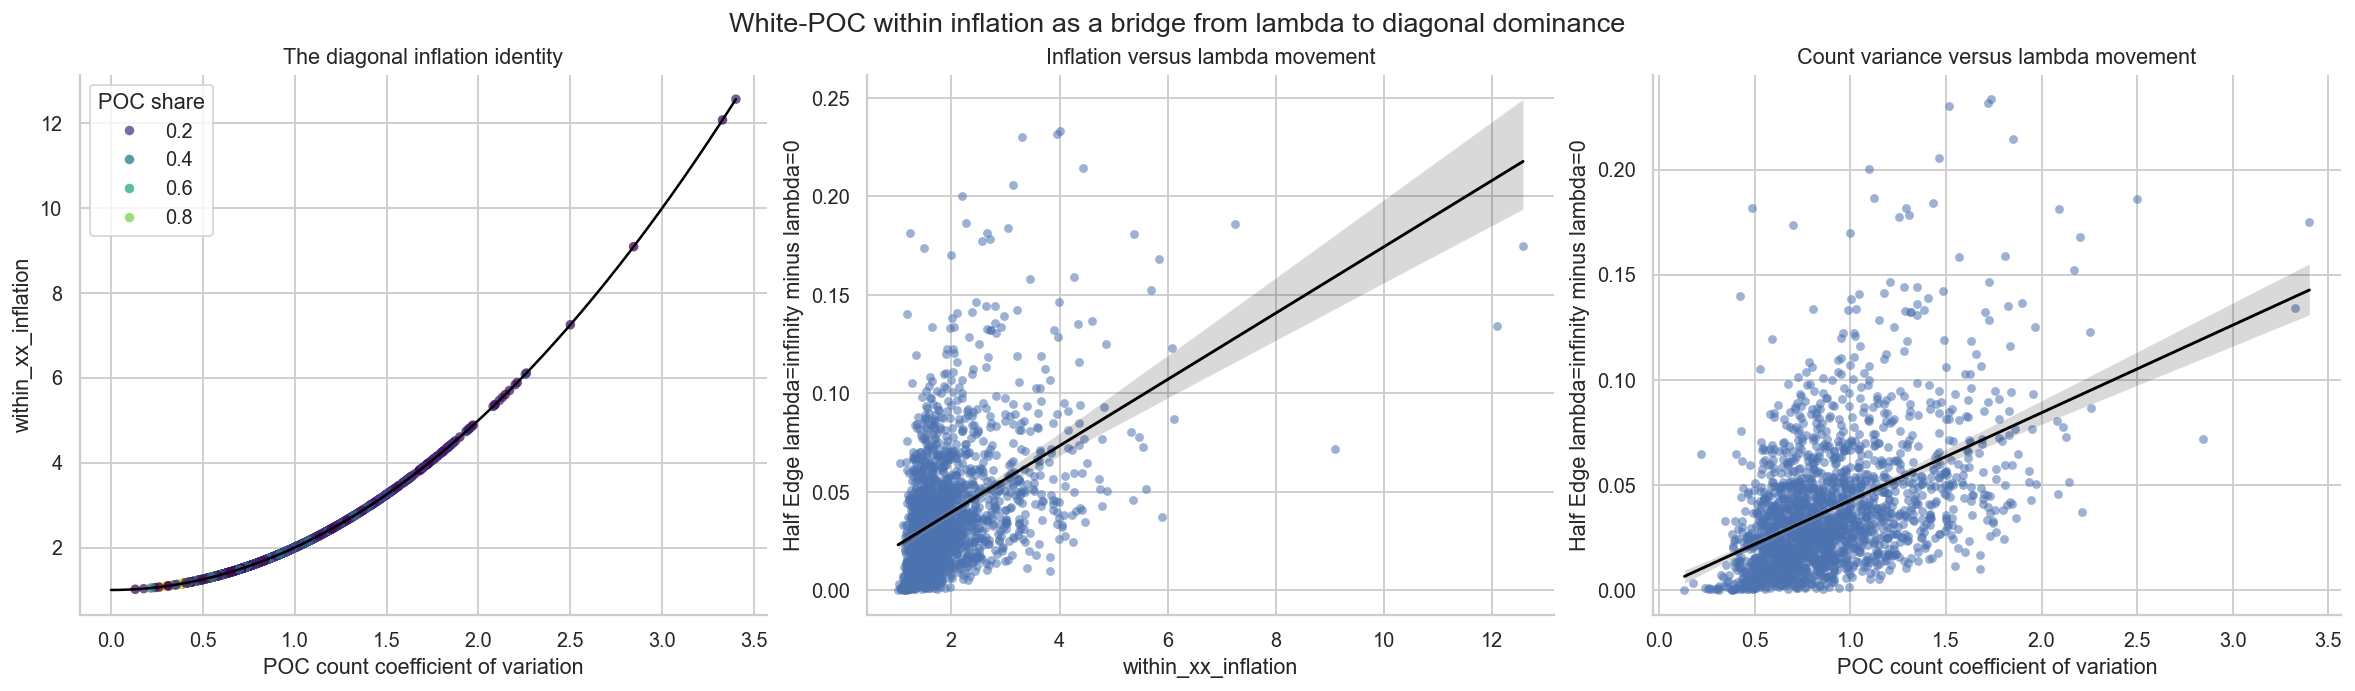

In [8]:
plot_data = within_diagnostics.dropna(
    subset=["poc_count_cv", "within_xx_inflation", "lambda_lim_minus_0", "total_x"]
).copy()

fig, axes = plt.subplots(ncols=3, figsize=(18, 5.2), constrained_layout=True)

sns.scatterplot(
    data=plot_data,
    x="poc_count_cv",
    y="within_xx_inflation",
    hue="total_x",
    palette="viridis",
    s=28,
    alpha=0.75,
    linewidth=0,
    ax=axes[0],
)
cv_grid = np.linspace(0, plot_data["poc_count_cv"].max(), 200)
axes[0].plot(cv_grid, 1 + cv_grid**2, color="black", linewidth=1.4, label="1 + poc_count_cv^2")
axes[0].set_xlabel("POC count coefficient of variation")
axes[0].set_ylabel("within_xx_inflation")
axes[0].set_title("The diagonal inflation identity")

sns.regplot(
    data=plot_data,
    x="within_xx_inflation",
    y="lambda_lim_minus_0",
    scatter_kws={"s": 24, "alpha": 0.55, "linewidths": 0},
    line_kws={"color": "black", "linewidth": 1.6},
    ax=axes[1],
)
axes[1].set_xlabel("within_xx_inflation")
axes[1].set_ylabel("Half Edge lambda=infinity minus lambda=0")
axes[1].set_title("Inflation versus lambda movement")

sns.regplot(
    data=plot_data,
    x="poc_count_cv",
    y="lambda_lim_minus_0",
    scatter_kws={"s": 24, "alpha": 0.55, "linewidths": 0},
    line_kws={"color": "black", "linewidth": 1.6},
    ax=axes[2],
)
axes[2].set_xlabel("POC count coefficient of variation")
axes[2].set_ylabel("Half Edge lambda=infinity minus lambda=0")
axes[2].set_title("Count variance versus lambda movement")

legend = axes[0].get_legend()
if legend is not None:
    legend.set_title("POC share")

fig.suptitle("White-POC within inflation as a bridge from lambda to diagonal dominance", fontsize=15)
plt.show()

## Scoped Takeaway

The lambda sweep shows that White-POC Half Edge becomes more dissimilarity-like and less Moran-like as same-tract products receive more weight.

The decomposition shows a first mechanical reason those same-tract products can become large: `within_xx` is a sum of squared tract POC counts, so it grows with tract-level POC count variance even when the area-level mean is fixed.

This supports the first layer of the conjecture. It does not, by itself, prove that `within_xx` inflation fully explains when Half Edge diverges from Moran under placement changes; that is the next layer to test with the placement-swing data.